# Study 1 Interview Analysis

This notebook analyzes the interview questionnaire data (`Study 1 Interview_9_9.csv`) to compare **Mid-air** and **Haptic** conditions using the Wilcoxon signed-rank test. Visualizations include boxplots and barplots.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set presentation style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Loading
Load the CSV and define the columns for the paired comparisons.

In [18]:
df = pd.read_csv("Study 1 Interview.csv")

# Define the question pairs
questions = {
    'Q2 (Control)': {
        'midair': '2、I felt in control of the stylus throughout the task.—mid-air',
        'haptic': '2、haptic'
    },
    'Q3 (Reach Target)': {
        'midair': '3、I could reach the target position easily (without frequent corrective adjustments).—mid-air',
        'haptic': '3、haptic'
    },
    'Q4 (Perceive Height)': {
        'midair': '4、I could perceive and understand the height I was creating or editing.—mid-air',
        'haptic': '4、haptic'
    },
    'Q5 (Prefer for VR)': {
        'midair': '5、I would like to use this interaction method for 3D content creation tasks in VR.—mid-air',
        'haptic': '5、haptic'
    }
}

display(df.head())

,序号,提交答卷时间,所用时间,来源,来源详情,来自IP,总分,1、User ID,2、I felt in control of the stylus throughout the task.—mid-air,2、haptic,3、I could reach the target position easily (without frequent corrective adjustments).—mid-air,3、haptic,4、I could perceive and understand the height I was creating or editing.—mid-air,4、haptic,5、I would like to use this interaction method for 3D content creation tasks in VR.—mid-air,5、haptic
0,1,2026/3/17 10:25:56,29秒,链接,直接访问,110.65.147.238(广东-深圳),29,1,3,4,4,3,3,4,4,4
1,2,2026/3/17 11:07:31,893秒,链接,直接访问,110.65.147.238(广东-深圳),29,2,5,3,4,3,3,4,3,4
2,3,2026/3/17 13:34:39,46秒,链接,直接访问,110.65.147.238(广东-深圳),32,3,5,4,4,3,3,5,4,4
3,4,2026/3/17 14:58:46,176秒,链接,直接访问,110.65.147.238(广东-深圳),26,4,2,4,2,5,1,5,2,5
4,5,2026/3/17 15:39:59,205秒,链接,直接访问,110.65.147.238(广东-深圳),30,5,4,4,4,3,3,4,4,4


## 2. Statistical Testing (Wilcoxon Signed-Rank Test)
Because the data consists of paired ordinal Likert scale responses (1-5), the Wilcoxon signed-rank test is appropriate to test for significant differences between conditions.

In [19]:
results = []

for q_name, cols in questions.items():
    midair_scores = df[cols['midair']]
    haptic_scores = df[cols['haptic']]
    
    # Wilcoxon signed-rank test
    stat, p_val = stats.wilcoxon(midair_scores, haptic_scores)
    
    # Calculate statistics
    midair_mean = midair_scores.mean()
    haptic_mean = haptic_scores.mean()
    midair_std = midair_scores.std()
    haptic_std = haptic_scores.std()
    
    results.append({
        'Question': q_name,
        'Mid-air Mean (SD)': f"{midair_mean:.2f} ({midair_std:.2f})",
        'Haptic Mean (SD)': f"{haptic_mean:.2f} ({haptic_std:.2f})",
        'W-Statistic': stat,
        'p-value': p_val,
        'Significant (p<0.05)': p_val < 0.05
    })

results_df = pd.DataFrame(results)
display(results_df)

/opt/anaconda3/envs/figure/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/opt/anaconda3/envs/figure/lib/python3.8/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Question,Mid-air Mean (SD),Haptic Mean (SD),W-Statistic,p-value,Significant (p<0.05)
0,Q2 (Control),3.86 (0.95),3.71 (0.47),23.0,0.626748,False
1,Q3 (Reach Target),3.29 (1.20),3.50 (1.02),35.0,0.741782,False
2,Q4 (Perceive Height),2.71 (0.91),4.43 (0.51),0.0,0.001214,True
3,Q5 (Prefer for VR),3.14 (1.17),4.43 (0.51),0.0,0.010909,True


## 3. Visualization
Transform the data to a long format to allow for straightforward visualization using seaborn.

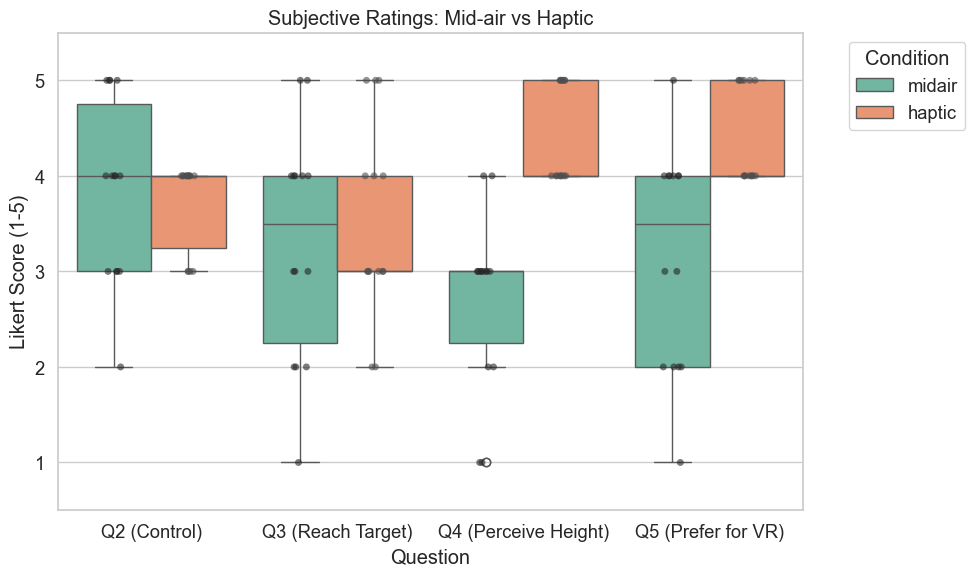

In [20]:
# Reshape data to long format
plot_data = []
for q_name, cols in questions.items():
    for index, row in df.iterrows():
        plot_data.append({'User ID': row['1、User ID'], 'Question': q_name, 'Condition': 'midair', 'Score': row[cols['midair']]})
        plot_data.append({'User ID': row['1、User ID'], 'Question': q_name, 'Condition': 'haptic', 'Score': row[cols['haptic']]})

df_long = pd.DataFrame(plot_data)

# Boxplot visualization with individual points
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df_long, x='Question', y='Score', hue='Condition', palette='Set2')
sns.stripplot(data=df_long, x='Question', y='Score', hue='Condition', dodge=True, 
              palette='dark:0.3', alpha=0.6, ax=ax, legend=False)

plt.title('Subjective Ratings: Mid-air vs Haptic')
plt.ylabel('Likert Score (1-5)')
plt.ylim(0.5, 5.5)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

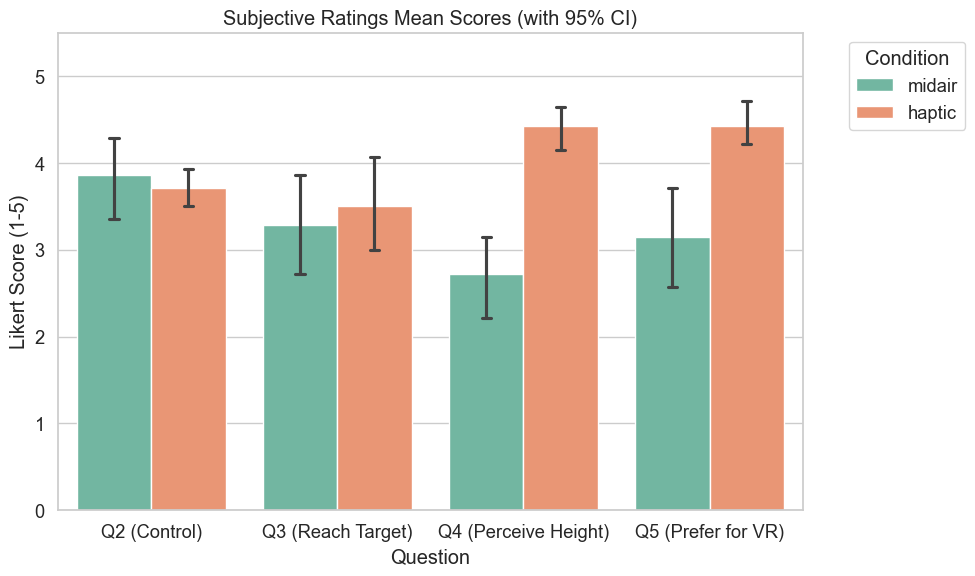

In [21]:
# Barplot visualization showing means and 95% Confidence Intervals
plt.figure(figsize=(10, 6))
sns.barplot(data=df_long, x='Question', y='Score', hue='Condition', palette='Set2', capsize=.1)

plt.title('Subjective Ratings Mean Scores (with 95% CI)')
plt.ylabel('Likert Score (1-5)')
plt.ylim(0, 5.5)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Diverging Stacked Bar Chart
A diverging stacked bar chart centered at the Neutral rating, matching the style requested.

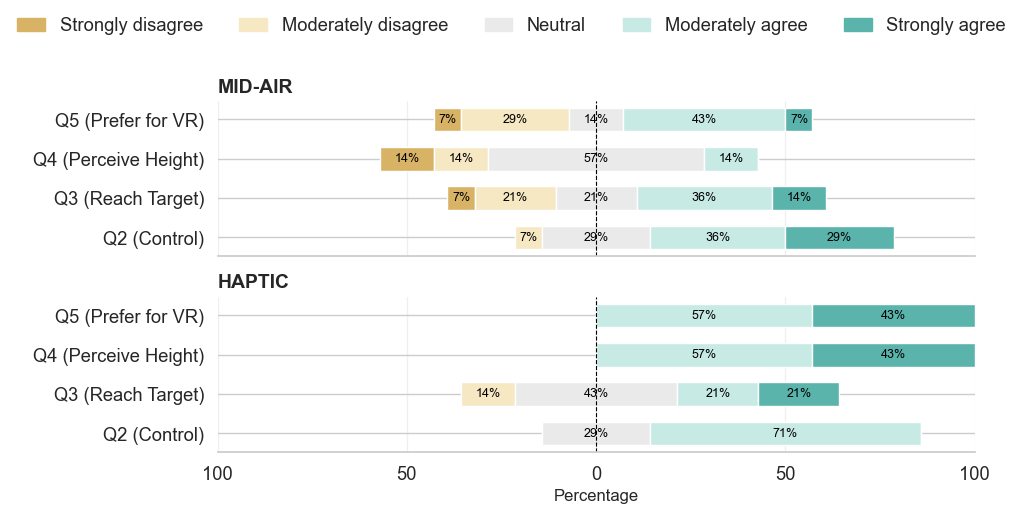

In [22]:
def draw_diverging_bar_chart(df_long):
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    
    conditions = ['midair', 'haptic']
    questions_list = ['Q2 (Control)', 'Q3 (Reach Target)', 'Q4 (Perceive Height)', 'Q5 (Prefer for VR)']
    
    summary = df_long.groupby(['Condition', 'Question', 'Score']).size().unstack(fill_value=0)
    summary = summary.div(summary.sum(axis=1), axis=0) * 100
    for i in range(1, 6):
        if i not in summary.columns:
            summary[i] = 0.0
    summary = summary[[1, 2, 3, 4, 5]]
    
    # Colors inspired by the provided image
    color_map = {
        1: '#d8b365', # Strongly disagree
        2: '#f6e8c3', # Moderately disagree
        3: '#eaeaea', # Neutral
        4: '#c7eae5', # Moderately agree
        5: '#5ab4ac'  # Strongly agree
    }
    
    fig, axes = plt.subplots(len(conditions), 1, figsize=(10, 5), sharex=True)
    if len(conditions) == 1:
        axes = [axes]
        
    for idx, cond in enumerate(conditions):
        ax = axes[idx]
        cond_data = summary.loc[cond].loc[questions_list]
        
        # For diverging, center of 'Neutral' (3) is at 0
        left_offset = - (cond_data[1] + cond_data[2] + cond_data[3]/2)
        
        for score in [1, 2, 3, 4, 5]:
            widths = cond_data[score]
            bars = ax.barh(questions_list, widths, left=left_offset, color=color_map[score], height=0.6)
            
            # Add text labels for percentages > 0
            for bar, width in zip(bars, widths):
                if width > 0:
                    x = bar.get_x() + width / 2
                    y = bar.get_y() + bar.get_height() / 2
                    ax.text(x, y, f'{int(round(width))}%', ha='center', va='center', fontsize=9, color='black')
                    
            left_offset += widths
            
        # Title matching the style
        display_cond = 'MID-AIR' if cond == 'midair' else 'HAPTIC'
        ax.set_title(display_cond, loc='left', fontsize=14, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlim(-100, 100)
        ax.set_xticks([-100, -50, 0, 50, 100])
        ax.set_xticklabels(['100', '50', '0', '50', '100'])
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.grid(axis='x', linestyle='-', alpha=0.3)
        ax.set_ylabel('') # remove ylabel as asked by the visual clean up
        
    axes[-1].set_xlabel('Percentage', fontsize=12)
    
    labels = ['Strongly disagree', 'Moderately disagree', 'Neutral', 'Moderately agree', 'Strongly agree']
    patches = [mpatches.Patch(color=color_map[i], label=labels[i-1]) for i in [1, 2, 3, 4, 5]]
    fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False, handlelength=1.5)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

draw_diverging_bar_chart(df_long)
